# Insper - Modelagem e Simulação do Mundo Físico

## Atividade - ODEINT em sistemas (Parte 2)

----

### Introdução

Como você já deve saber, os códigos compilados no Jupyter Notebook rodam um na sequência do outro. Se você declara uma variável no começo, pode utilizar essa mesma variável mais adiante.

Dessa forma, vamos já importar todas as bibliotecas que serão utilizadas nessa atividade, para não precisarmos importar novamente. Para tal, basta rodar o código abaixo antes de ir para o próximo item.

In [2]:
# Importa bibliotecas necessárias
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

----

### Item 1 - Primeira iteração do problema dos tanques

#### a) 

Em aula, encontramos as equações diferenciais que representam um modelo de dois tanques:

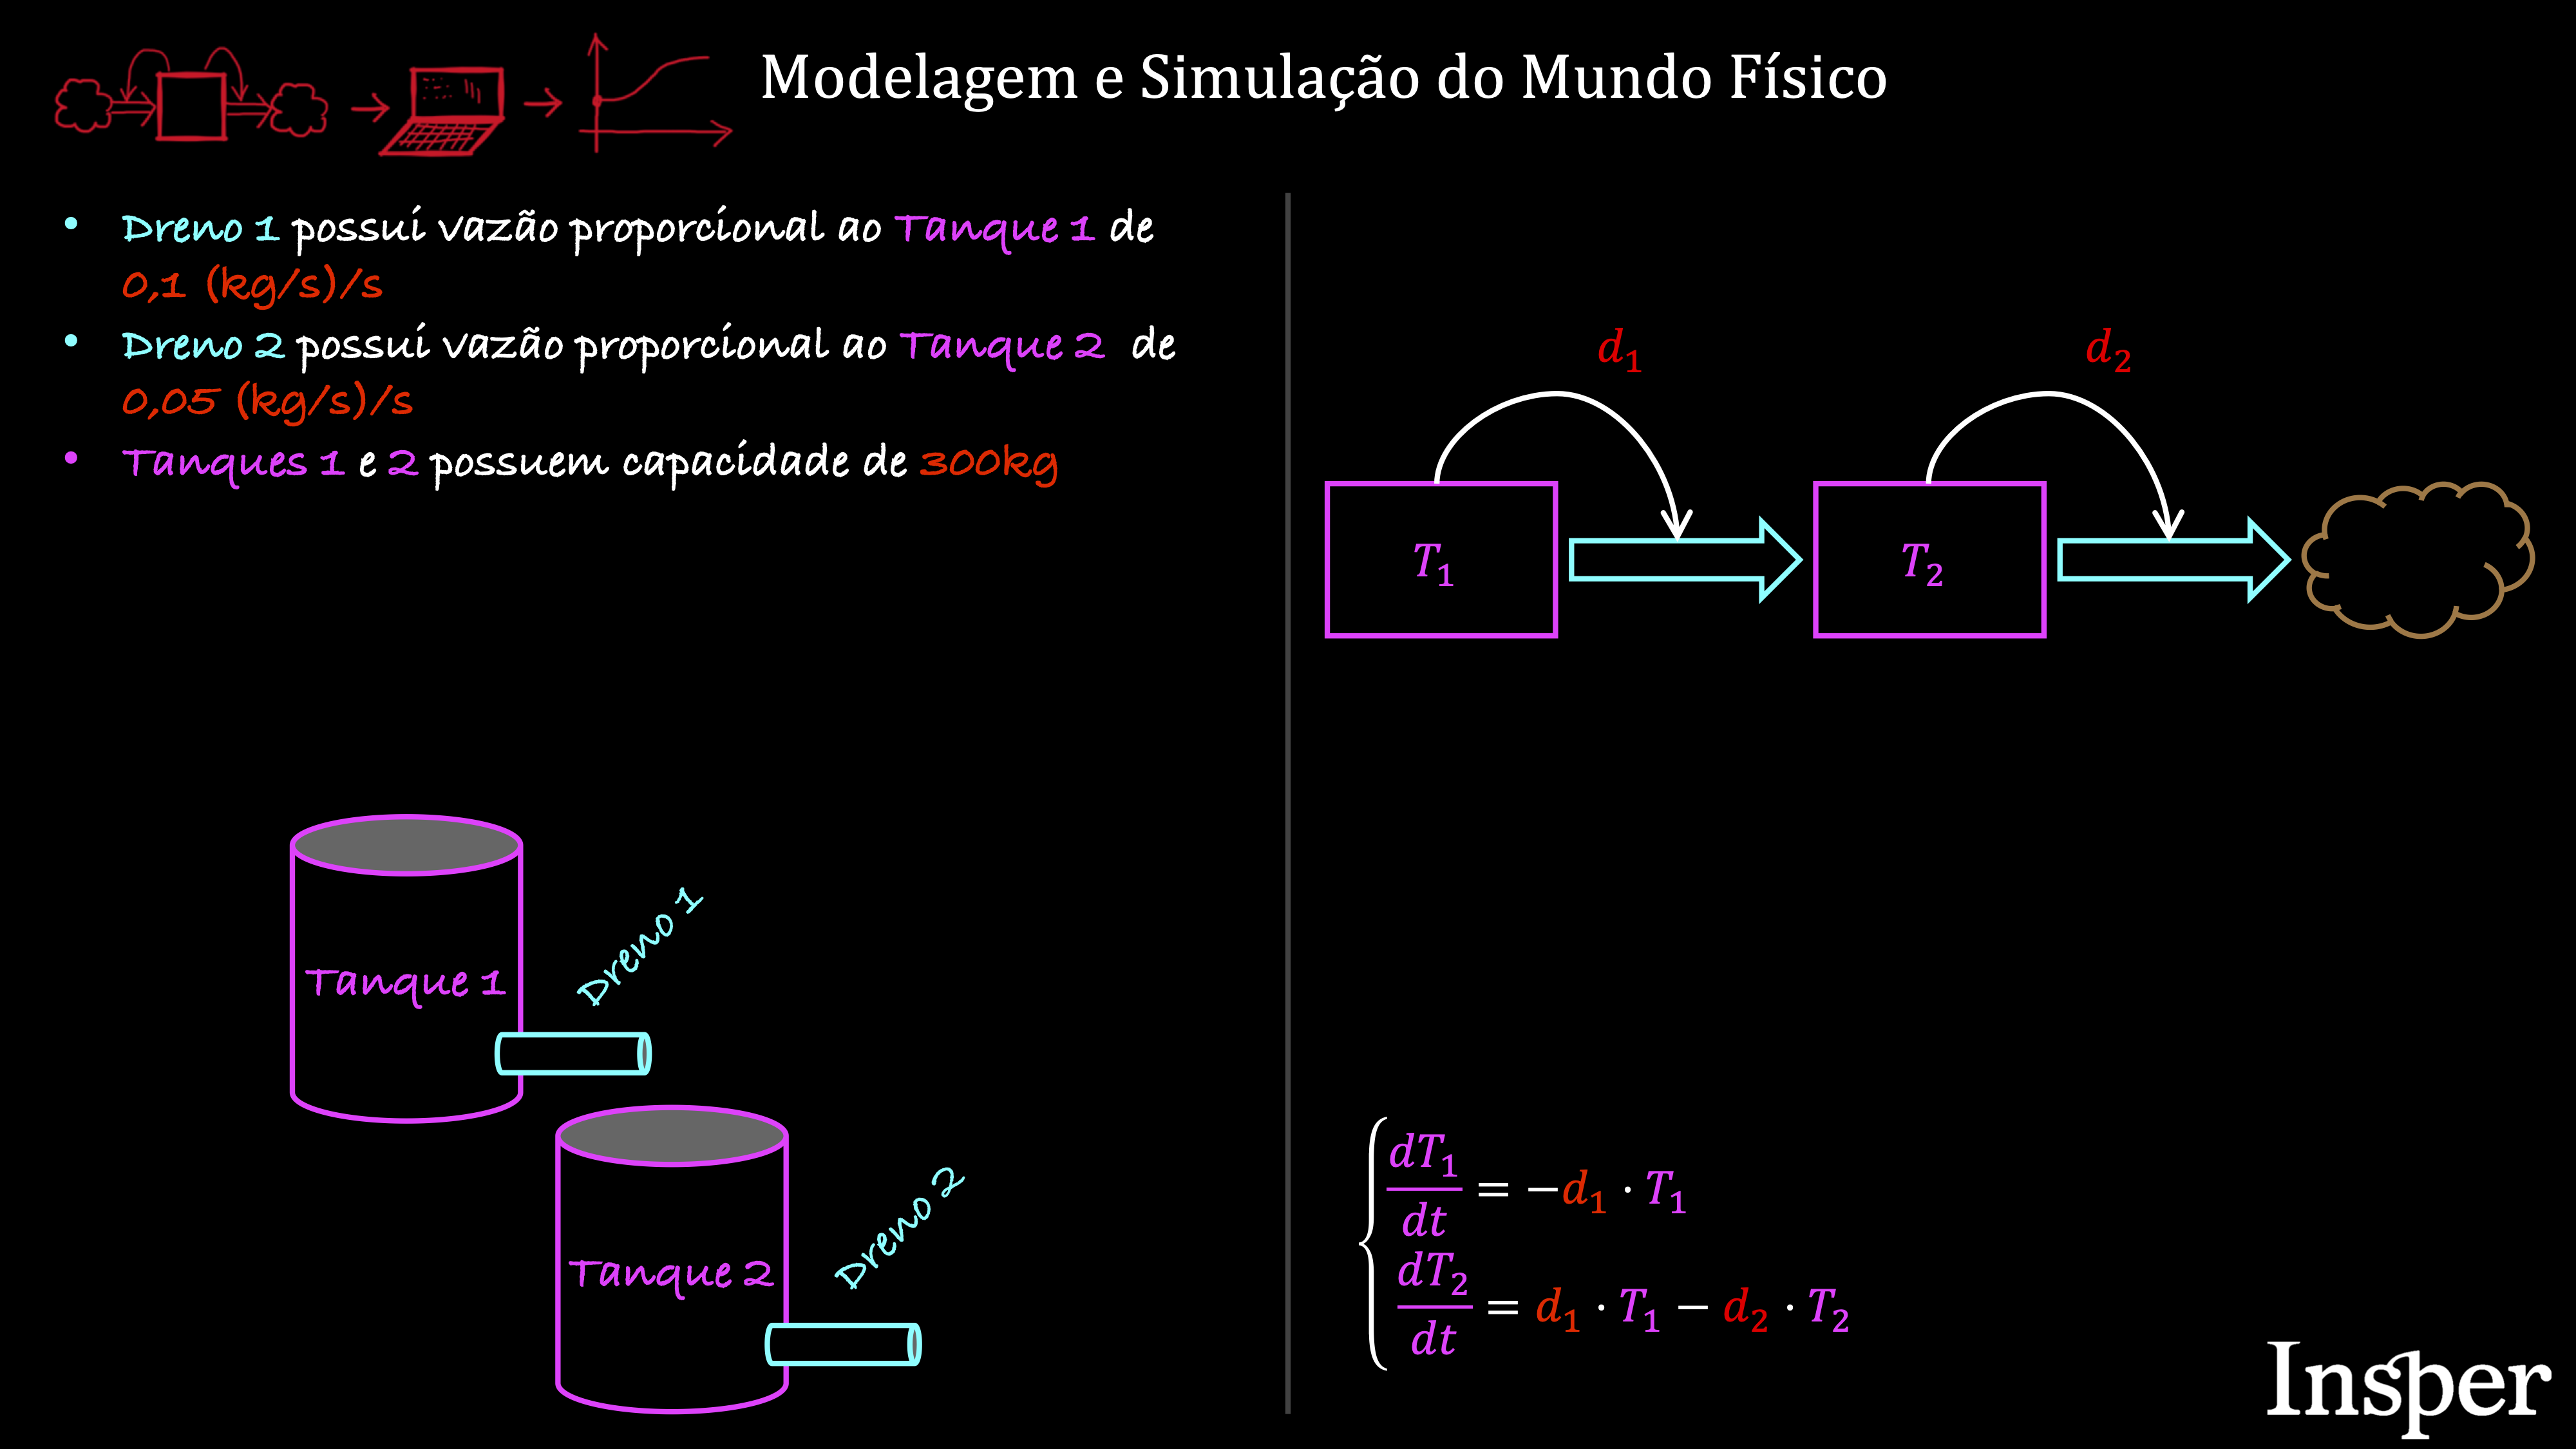

#### a) Modelo

Implemente uma função que recebe uma lista com os estoques $x = [T_1 \quad T_2]$ e o instante de tempo $t$ e retorna uma lista com as derivadas dos estoques $\frac{dx}{dt} = [\frac{dT_1}{dt} \quad \frac{dT_2}{dt}]$.

In [3]:
def modelo(x,t):
    T1=x[0]
    T2=x[1]
    dT1dt=-0.1*T1
    dT2dt=0.1*T1-0.05*T2
    return [dT1dt, dT2dt]

#### b) Resolução numérica

Usando a função que você implementou no item anterior, calcule uma lista com uma lista de valores $[[T_1(0) \quad T_1(t_1) \quad \cdots \quad T_1(t_n)]$,$[T_2(0) \quad T_2(t_1) \quad \cdots \quad T_2(t_n)]]$ utilizando a função ```odeint```. Para isso, você vai precisar de:

- Uma lista com as condições iniciais $T_1(0) = 300$kg e $T_2(0) = 0$kg
- Uma lista de tempo $[0 \quad t_1 \quad \cdots \quad t_n]$ com $\Delta t$ bem pequeno (use $\Delta t=10^{-3}s$ em uma lista de tempo de $0$ a $200$s)

In [4]:
t=np.arange(0,200,1e-3)
lista_T1=odeint(modelo,[300,0], t)[:,0]
lista_T2=odeint(modelo,[300,0], t)[:,1]

#### c) Gráfico

Por fim, plote um gráfico de $T_1(t)$ e $T_2(t)$ por $t$ (utilize o mesmo par de eixos).

Text(0, 0.5, 'Litros')

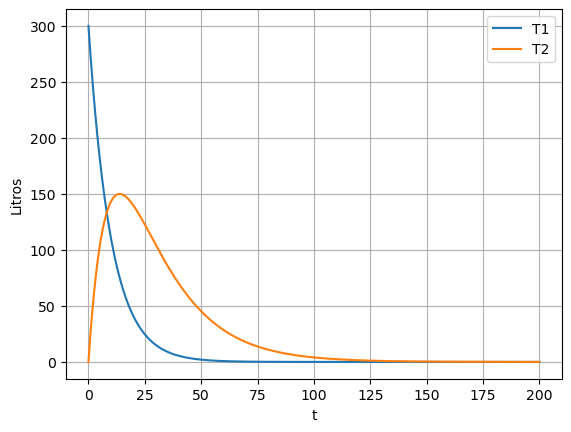

In [5]:
plt.plot(t, lista_T1, label="T1")
plt.plot(t, lista_T2, label="T2")
plt.grid()
plt.legend()
plt.xlabel("t")
plt.ylabel("Litros")



----

### Item 2 - Segunda iteração do problema dos tanques

Em aula, também encontramos as equações diferenciais que representam uma 2ª iteração do modelo de dois tanques, com a adição de uma bomba e uma válvula no sistema:

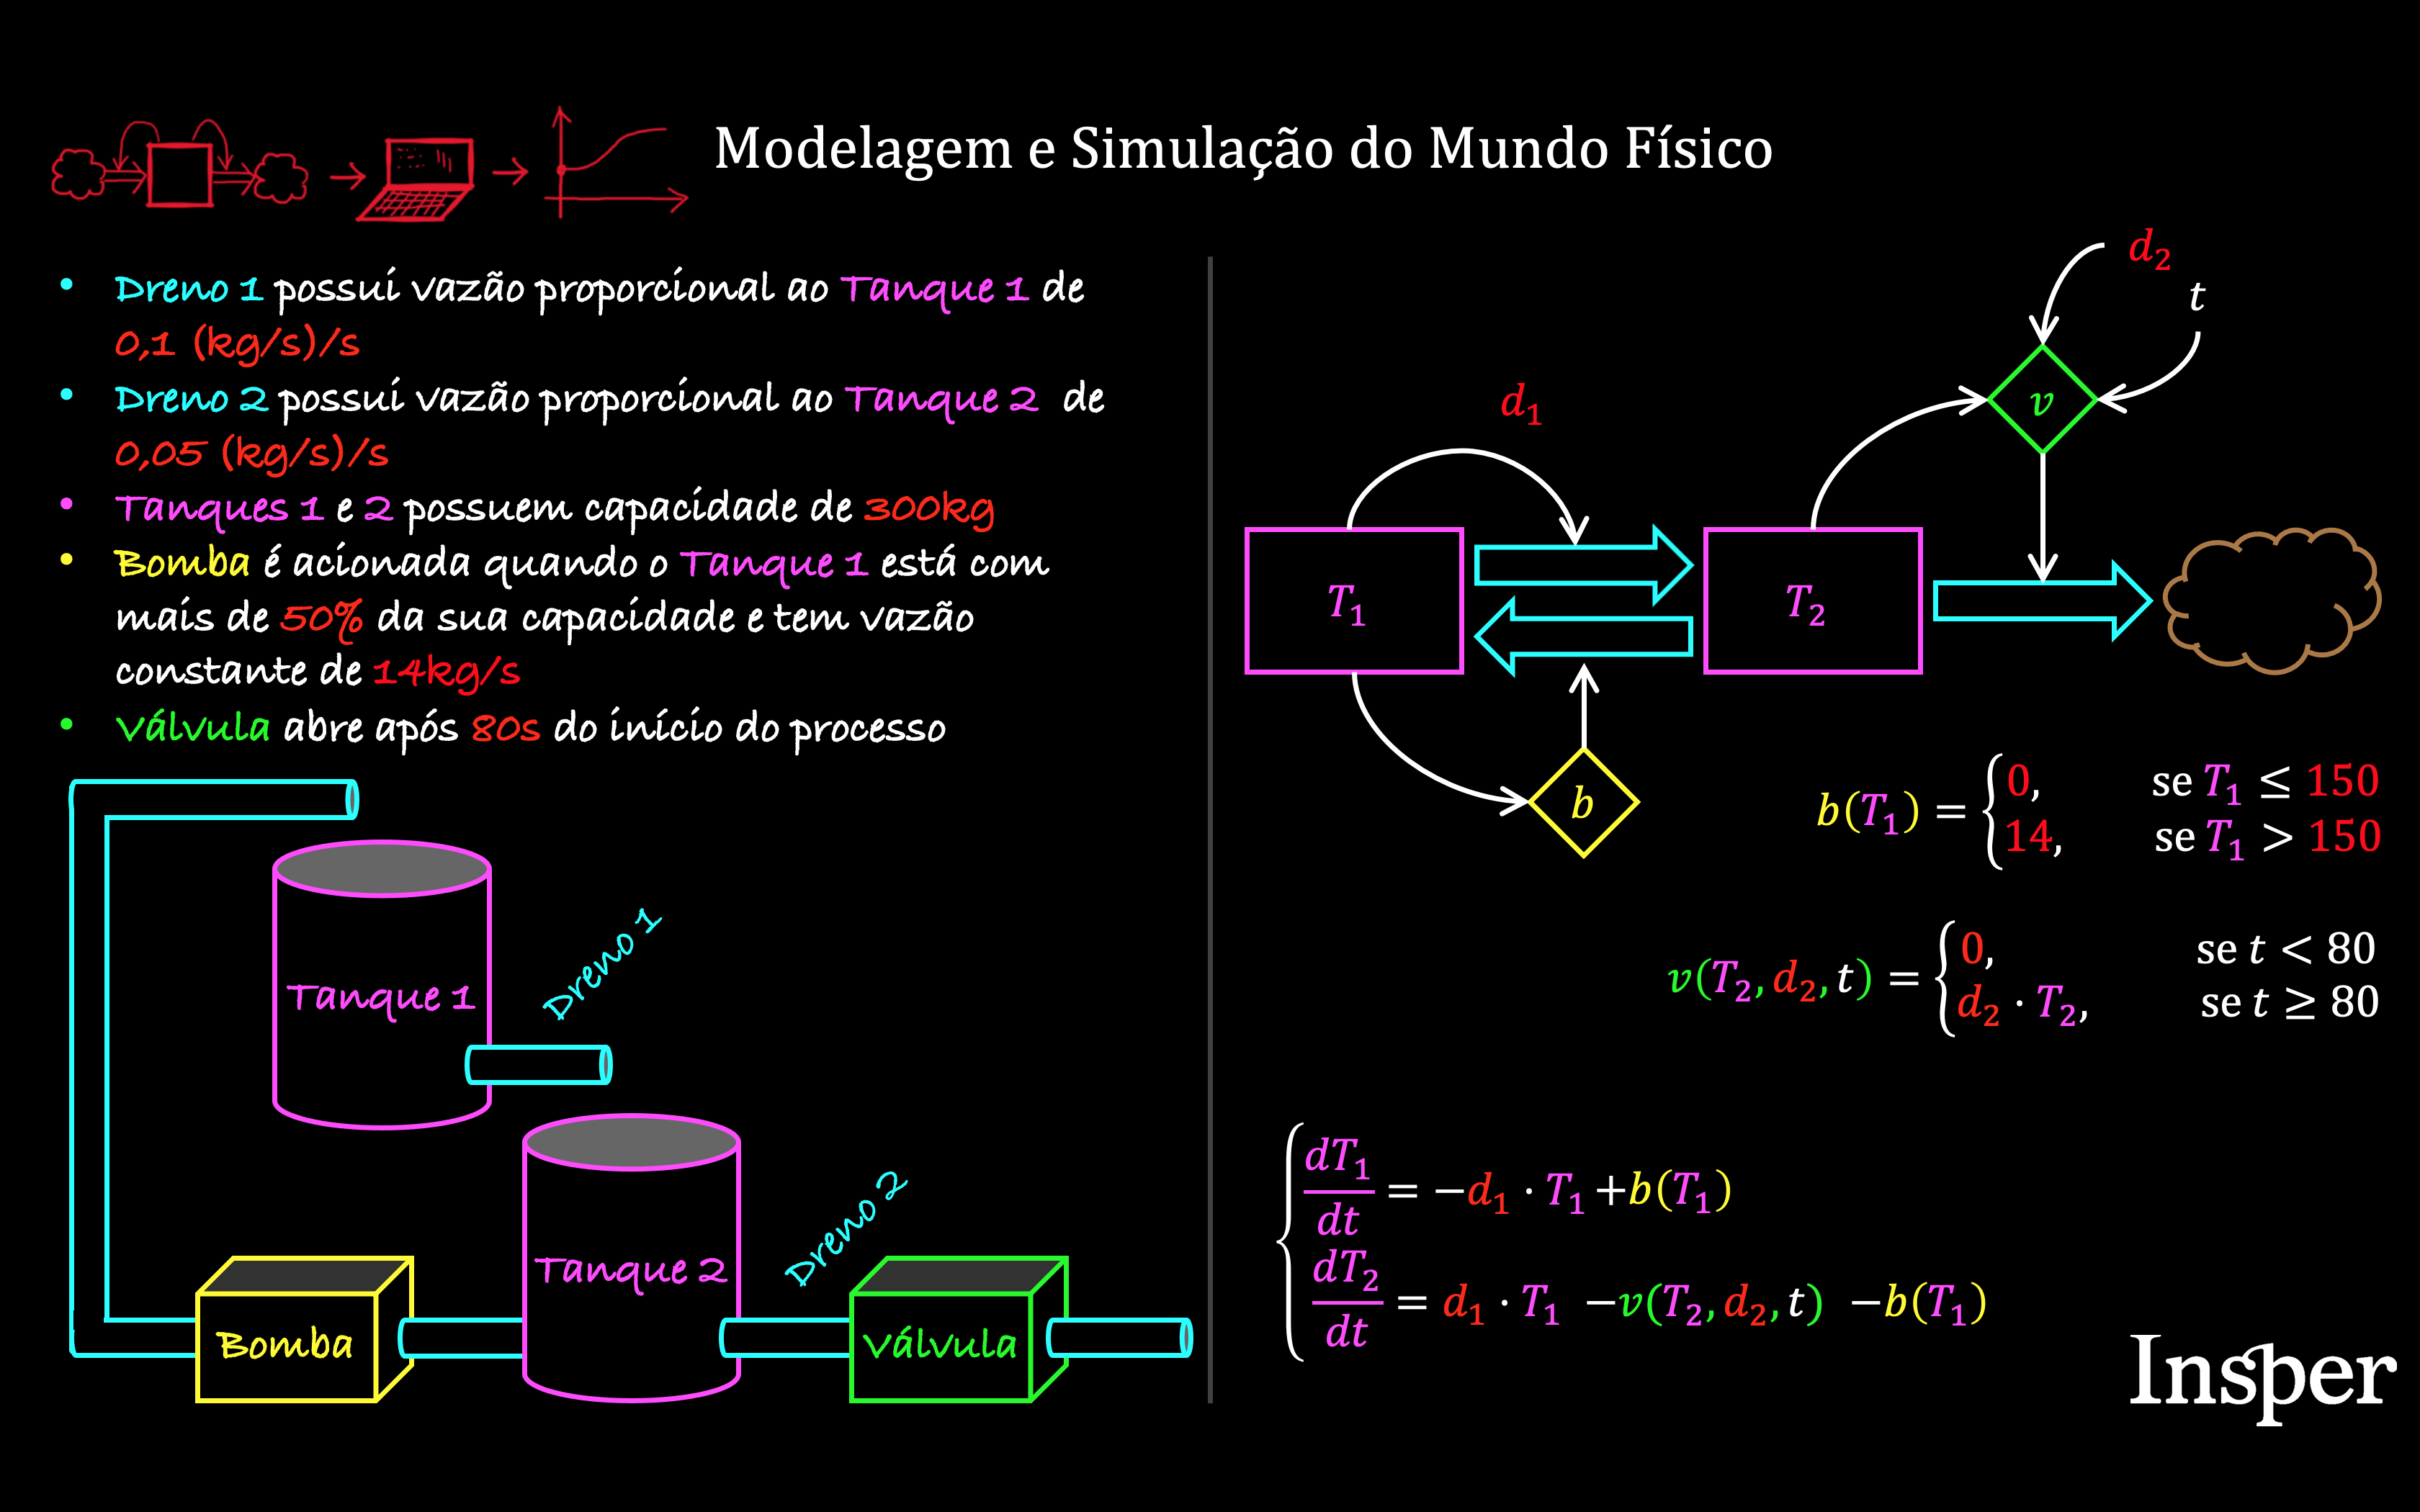

#### a) Funções

Implemente as funções $b(T_1)$ e $v(T_2, d_2, t)$ do nosso modelo, correspondentes ao funcionamento da bomba e da válvula, respectivamente.

In [6]:
def b(T1):
    if T1<=150:
        b=0
    else:
        b=14
    return b
def v(T2,d2,t):
    if t<80:
        v=0
    else:
        v=d2*T2
    return v
    

#### b) Modelo

Reimplemente a função que calcula as derivadas utilizando as funções que você implementou no item anterior.

In [7]:
d2=0.05
def dTdt(x,t):
    T1=x[0]
    T2=x[1]
    dT1dt=-0.1*T1+b(T1)
    dT2dt=0.1*T1-v(T2,d2,t)-b(T1)
    return [dT1dt,dT2dt]

#### c) Resolução numérica

Calcule novamente uma lista com uma lista de valores $[[T_1(0) \quad T_1(t_1) \quad \cdots \quad T_1(t_n)]$,$[T_2(0) \quad T_2(t_1) \quad \cdots \quad T_2(t_n)]]$ utilizando a função ```odeint```. Utilize as mesmas condições iniciais e lista de tempo do **item 1**.

In [8]:
t=np.arange(0,200,1e-3)
lista_T1=odeint(dTdt,[300,0], t)[:,0]
lista_T2=odeint(dTdt,[300,0],t)[:,1]

#### d) Gráfico

Plote novamente os gráficos de $T_1(t)$ e $T_2(t)$ por $t$ (utilize o mesmo par de eixos). Verifique se os resultados estão diferentes do **item 1c** e se fazem sentido.

Text(0, 0.5, 'Litros')

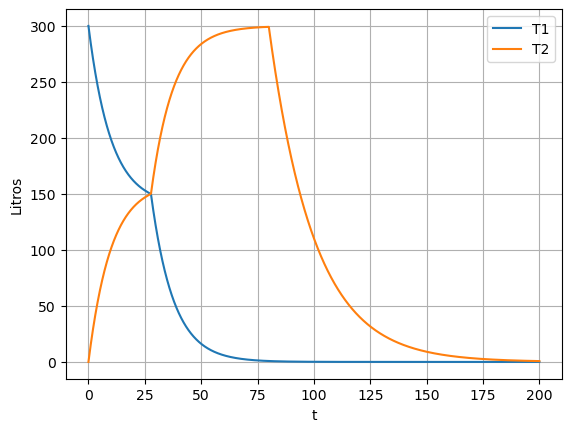

In [9]:
plt.plot(t, lista_T1, label="T1")
plt.plot(t, lista_T2, label="T2")
plt.grid()
plt.legend()
plt.xlabel("t")
plt.ylabel("Litros")

----

### Item 3 - Efeito da vazão da bomba na dinâmica do tanque 1

Agora, vamos ver como a variação da vazão da bomba afeta a dinâmica do tanque 1. Para fazer isso, você irá gerar diferentes curvas de $T_1(t)$, cada uma delas para um valor diferente da vazão da bomba.

#### a) Alterações

Copie e cole no espaço abaixo a definição da função $b(T_1)$ que você definiu no **item 2a**. Em seguida, modifique-a de tal modo que a vazão da bomba, em vez de ser constante e igual a $14$, seja dada por um  parâmetro $V_b\,$ que é recebido pela função. Ou seja, a função $b(T_1)$ passará a ser $b(T_1, V_b)$. Da mesma forma, copie a função do **item 2b**, alterando-a para também receber a vazão como parâmetro. Por exemplo, se sua função do item **2a** era definida por `modelo(x, t)`, agora ela passa a ser definida por `modelo(x, t, Vb)`.

In [27]:
def b(T1,Vb):
    if T1<=150:
        return 0
    else:
        return Vb

d2=0.05

def dTdt(x,t,Vb):
    T1=x[0]
    T2=x[1]
    dT1dt=-0.1*T1+b(T1,Vb)
    dT2dt=0.1*T1-v(T2,d2,t)-b(T1,Vb)
    return [dT1dt,dT2dt]


#### b) Gráfico

Agora, defina uma lista com os seguintes valores do parâmetro $V_b$: $[6 \quad 7 \quad 8 \quad \ldots \quad 20  \quad 21 \quad 22]$. 

Em seguida, implemente um loop em que `odeint` é executada para cada um desses valores de $V_b$. Para fazer isso, é necessário fornecer um argumento adicional para `odeint` usando a seguinte sintaxe:

`odeint(modelo, x_0, t_lista, args=(Vb,))`

Use as mesmas condições iniciais e lista de tempo dos itens anteriores.

Plote, **em uma mesma figura**, os gráficos de $T_1(t)$ por $t$ para cada valor da vazão $V_b$ da lista anterior.

**Observação: este item aborda parte do que veremos na próxima aula. Caso sinta dificuldade, faça antes a leitura prévia da aula 13.**

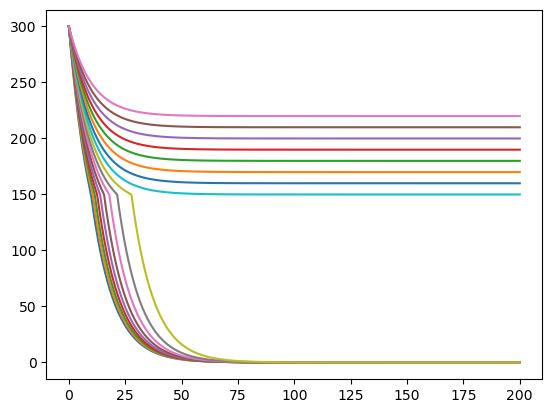

In [28]:
lista_Vb=np.arange(6,23,1)

i=0

while i<(len(lista_Vb)):
    k=odeint(dTdt, [300,0], t, args=(lista_Vb[i],))
    plt.plot(t,k[:,0])
    i+=1
plt.show()